In [14]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

In [15]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [17]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [6]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [7]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [9]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [ ]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    # filename = title.lower().replace(" ", "_") + ".md"
    # output_path = Path(filename)
    # output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [11]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

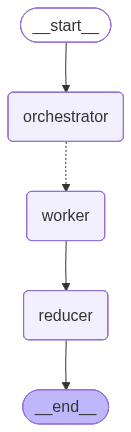

In [12]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [23]:
out = app.invoke({"topic": "Write a blog on Transformers", "sections": []})

In [18]:

print(out["final"])

# Unveiling the Power of Transformers: The AI Architecture Revolutionizing Everything

## Beyond Recurrent Networks: A New Era of AI

For years, Recurrent Neural Networks (RNNs) and their sophisticated cousin, Long Short-Term Memory (LSTM) networks, were the undisputed champions of sequential data processing. They powered early advancements in machine translation, speech recognition, and text generation by meticulously processing information step-by-step. However, their sequential nature brought inherent limitations, particularly in handling long-range dependencies and struggling with parallelization. Then, in 2017, a revolutionary paper titled "Attention Is All You Need" introduced the world to the Transformer architecture. This groundbreaking deep learning model completely re-imagined how AI processes sequences, fundamentally departing from recurrence by leveraging a novel "self-attention" mechanism. This paradigm shift not only overcame the bottlenecks of its predecessors but also u

In [20]:
print(out)

{'topic': 'Write a blog on Transformers', 'plan': Plan(blog_title='Unveiling the Power of Transformers: The AI Architecture Revolutionizing Everything', tasks=[Task(id=1, title='Beyond Recurrent Networks: A New Era of AI', brief='Introduce Transformers as a groundbreaking deep learning architecture, highlighting their departure from traditional RNNs/LSTMs and their immense impact on modern AI, especially in Natural Language Processing (NLP).'), Task(id=2, title='Deconstructing the Magic: How Self-Attention Works', brief='Explain the fundamental concept of the self-attention mechanism, illustrating how it allows the model to weigh the importance of different parts of an input sequence, thereby capturing long-range dependencies more effectively than previous architectures.'), Task(id=3, title='Building Blocks: Encoder, Decoder, and Parallel Processing', brief='Describe the general architecture of Transformers, including the encoder-decoder structure (or encoder-only for models like BERT)